In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [27]:
X,y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

In [28]:
df=pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df

,Feature 1,Feature 2
0,-9.113944,6.813616
1,-9.354576,7.092790
2,-2.015671,8.281780
3,-7.010236,-6.220843
4,-10.061202,6.718671
...,...,...
295,-3.199794,9.239705
296,4.142482,1.637061
297,-3.473688,9.125066
298,-8.827277,8.329385


In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [30]:
WCSS = []  #inertia values for different k values
k_values = range(1, 11)  #k values from 1 to 10

In [31]:
for K in k_values:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)
    

In [32]:
WCSS

[600.0,
 310.5381703928708,
 62.887904537290105,
 6.41544432945205,
 5.745211730430972,
 5.084397644041042,
 4.760615221836885,
 3.9596312987388496,
 3.591316584862052,
 3.32495460604448]

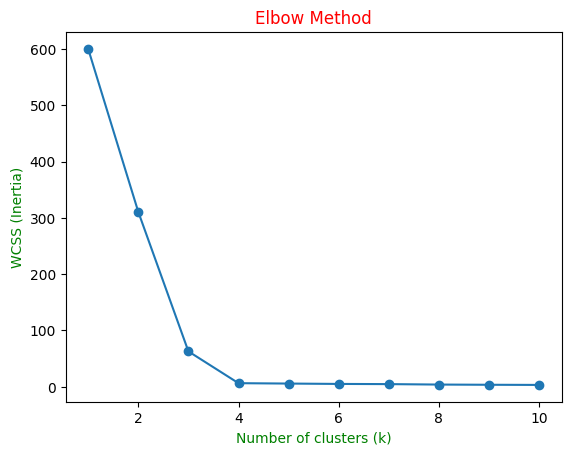

In [33]:
plt.plot(k_values, WCSS, marker='o')
plt.title('Elbow Method',color="red")
plt.xlabel('Number of clusters (k)',color="green")
plt.ylabel('WCSS (Inertia)',color="green")
plt.show()


In [34]:
k_means_final = KMeans(n_clusters=4, random_state=42)

In [35]:
cluster_labels = k_means_final.fit_predict(X_scaled)
cluster_labels

array([3, 3, 0, 1, 3, 1, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 3, 2, 0, 0, 2, 0,
       1, 3, 0, 3, 3, 1, 1, 2, 0, 2, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       0, 0, 3, 2, 3, 2, 1, 3, 1, 0, 1, 2, 3, 2, 2, 0, 3, 2, 2, 3, 1, 1,
       1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 1, 1, 0, 1, 0, 0, 3, 0, 1, 3, 3, 2,
       2, 2, 3, 0, 3, 0, 0, 3, 1, 0, 3, 3, 2, 2, 2, 0, 0, 0, 0, 0, 1, 3,
       2, 0, 0, 0, 0, 2, 3, 1, 3, 1, 1, 1, 0, 3, 1, 3, 3, 0, 3, 1, 2, 0,
       0, 0, 0, 2, 2, 3, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 3, 2, 1,
       0, 2, 1, 3, 3, 2, 0, 3, 1, 3, 2, 3, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 3, 0, 3, 2, 2, 3, 1, 0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2,
       2, 3, 0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 0, 1, 1, 2, 3, 1, 3, 3, 0, 3,
       3, 1, 3, 1, 2, 2, 3, 3, 2, 2, 2, 3, 0, 1, 2, 1, 3, 2, 3, 3, 3, 1,
       1, 2, 3, 1, 1, 1, 3, 1, 3, 1, 3, 2, 1, 3, 2, 0, 3, 0, 2, 0, 3, 0,
       1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 1, 0, 0, 2, 2, 2, 2, 1, 3, 2,
       1, 2, 2, 1, 0, 1, 2, 0, 3, 0, 2, 0, 3, 3], d

In [36]:
df['Cluster'] = cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

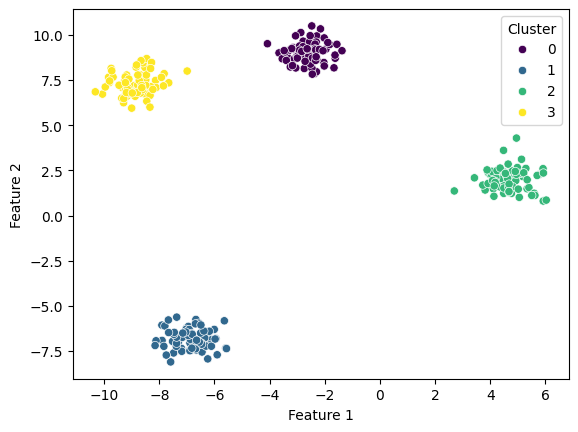

In [37]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='Cluster', palette='viridis')

# DBSCAN 

In [38]:
from sklearn.datasets import make_moons

In [39]:
X,y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [41]:
from sklearn.cluster import KMeans , DBSCAN

In [43]:
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df

,Feature 1,Feature 2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [45]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [48]:
df["kmeans_cluster"] = kmeans_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

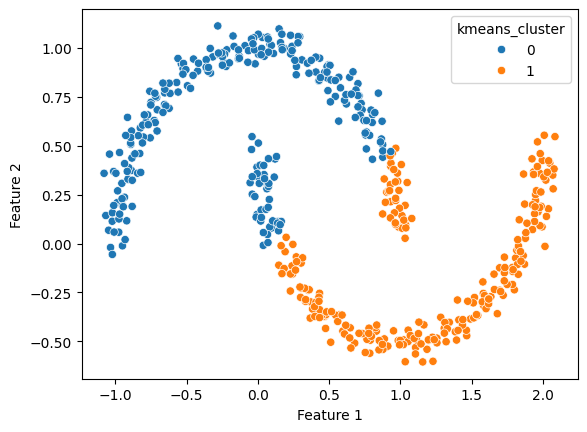

In [52]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='kmeans_cluster', palette='tab10')

In [53]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [54]:
df["dbscan_cluster"] = dbscan_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

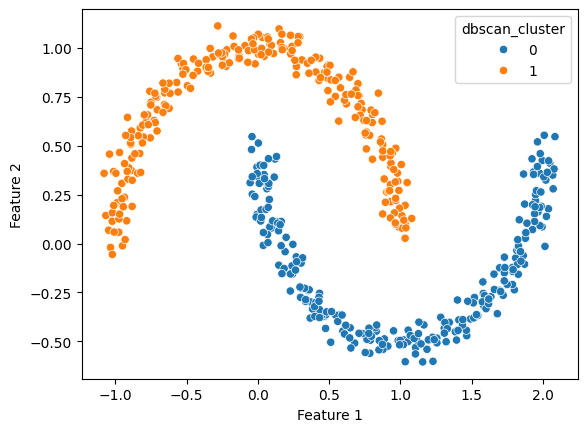

In [56]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='dbscan_cluster', palette='tab10')